In [64]:
import pandas as pd

In [65]:
df_normal = pd.read_csv('C:\\Users\\Gjirafa\\Alberti\\AlbZa\\DS Lab2\\Dataset\\SWaT_Dataset_Normal_v0.csv')
df_attack = pd.read_csv('C:\\Users\\Gjirafa\\Alberti\\AlbZa\\DS Lab2\\Dataset\\SWaT_Dataset_Attack_v0 - Copy.csv')

In [66]:
# Convert timestamps to datetime
df_normal['Timestamp'] = pd.to_datetime(df_normal['Timestamp'])


C:\Users\Gjirafa\AppData\Local\Temp\ipykernel_12452\2695623712.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_normal['Timestamp'] = pd.to_datetime(df_normal['Timestamp'])


In [67]:
df_normal.head()

,Timestamp,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,...,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,Normal/Attack
0,2015-12-22 16:00:00,2.470294,261.5804,2,2,1,244.3284,8.19008,306.101,2.471278,...,1,1,10.02948,0.0,4.277749,0.000256,1,1,1,Normal
1,2015-12-22 16:00:01,2.457163,261.1879,2,2,1,244.3284,8.19008,306.101,2.468587,...,1,1,10.02948,0.0,4.277749,0.000256,1,1,1,Normal
2,2015-12-22 16:00:02,2.439548,260.9131,2,2,1,244.3284,8.19008,306.101,2.467305,...,1,1,10.02948,0.0,4.277749,0.000256,1,1,1,Normal
3,2015-12-22 16:00:03,2.428338,260.2850,2,2,1,244.3284,8.19008,306.101,2.466536,...,1,1,10.02948,0.0,4.277749,0.000256,1,1,1,Normal
4,2015-12-22 16:00:04,2.424815,259.8925,2,2,1,244.4245,8.19008,306.101,2.466536,...,1,1,10.02948,0.0,4.277749,0.000256,1,1,1,Normal


In [68]:
df_normal.dtypes

Timestamp        datetime64[ns]
FIT101                  float64
LIT101                  float64
MV101                     int64
P101                      int64
P102                      int64
AIT201                  float64
AIT202                  float64
AIT203                  float64
FIT201                  float64
MV201                     int64
P201                      int64
P202                      int64
P203                      int64
P204                      int64
P205                      int64
P206                      int64
DPIT301                 float64
FIT301                  float64
LIT301                  float64
MV301                     int64
MV302                     int64
MV303                     int64
MV304                     int64
P301                      int64
P302                      int64
AIT401                  float64
AIT402                  float64
FIT401                  float64
LIT401                  float64
P401                      int64
P402    

In [69]:
df_attack['Timestamp'] = pd.to_datetime(df_attack['Timestamp'], format='mixed')
df_attack['Timestamp'] = df_attack['Timestamp'].dt.strftime('%Y-%m-%d %H:%M:%S')
df_attack.head()

,Timestamp,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,...,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,Normal/Attack
0,2015-12-28 10:00:00,2.427057,522.8467,2,2,1,262.0161,8.396437,328.6337,2.445391,...,2,1,250.8652,1.649953,189.5988,0.000128,1,1,1,Normal
1,2015-12-28 10:00:01,2.446274,522.8860,2,2,1,262.0161,8.396437,328.6337,2.445391,...,2,1,250.8652,1.649953,189.6789,0.000128,1,1,1,Normal
2,2015-12-28 10:00:02,2.489191,522.8467,2,2,1,262.0161,8.394514,328.6337,2.442316,...,2,1,250.8812,1.649953,189.6789,0.000128,1,1,1,Normal
3,2015-12-28 10:00:03,2.534350,522.9645,2,2,1,262.0161,8.394514,328.6337,2.442316,...,2,1,250.8812,1.649953,189.6148,0.000128,1,1,1,Normal
4,2015-12-28 10:00:04,2.569260,523.4748,2,2,1,262.0161,8.394514,328.6337,2.443085,...,2,1,250.8812,1.649953,189.5027,0.000128,1,1,1,Normal


In [70]:
df_attack['Timestamp'].min()

'2015-12-28 10:00:00'

In [71]:
df_normal['Timestamp'].max()

Timestamp('2015-12-28 09:59:59')

In [72]:
df_normal.shape

(496800, 53)

In [73]:
df_attack.shape

(449919, 53)

In [74]:
df_attack.dtypes

Timestamp         object
FIT101           float64
LIT101           float64
MV101              int64
P101               int64
P102               int64
AIT201           float64
AIT202           float64
AIT203           float64
FIT201           float64
MV201              int64
P201               int64
P202               int64
P203               int64
P204               int64
P205               int64
P206               int64
DPIT301          float64
FIT301           float64
LIT301           float64
MV301              int64
MV302              int64
MV303              int64
MV304              int64
P301               int64
P302               int64
AIT401           float64
AIT402           float64
FIT401           float64
LIT401           float64
P401               int64
P402               int64
P403               int64
P404               int64
UV401              int64
AIT501           float64
AIT502           float64
AIT503           float64
AIT504           float64
FIT501           float64


In [75]:
df = pd.concat([df_normal, df_attack])

In [76]:
df.shape

(946719, 53)

In [77]:
df_columns = df.columns

In [78]:
df = df.loc[:, df.nunique() > 1]

In [79]:
df.drop(['AIT201', 'P602'], axis=1, inplace=True)

In [80]:
df.columns

Index(['Timestamp', 'FIT101', 'LIT101', 'MV101', 'P101', 'P102', 'AIT202',
       'AIT203', 'FIT201', 'MV201', 'P201', 'P203', 'P204', 'P205', 'P206',
       'DPIT301', 'FIT301', 'LIT301', 'MV301', 'MV302', 'MV303', 'MV304',
       'P301', 'P302', 'AIT401', 'AIT402', 'FIT401', 'LIT401', 'P402', 'P403',
       'UV401', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502',
       'FIT503', 'FIT504', 'P501', 'PIT501', 'PIT502', 'PIT503', 'FIT601',
       'Normal/Attack'],
      dtype='object')

In [81]:
excluded_cols = [col for col in df_columns if col not in df.columns]
excluded_cols

['AIT201', 'P202', 'P401', 'P404', 'P502', 'P601', 'P602', 'P603']

In [82]:
df.rename(columns={'Normal/Attack': 'Attack'}, inplace=True)
df.columns

Index(['Timestamp', 'FIT101', 'LIT101', 'MV101', 'P101', 'P102', 'AIT202',
       'AIT203', 'FIT201', 'MV201', 'P201', 'P203', 'P204', 'P205', 'P206',
       'DPIT301', 'FIT301', 'LIT301', 'MV301', 'MV302', 'MV303', 'MV304',
       'P301', 'P302', 'AIT401', 'AIT402', 'FIT401', 'LIT401', 'P402', 'P403',
       'UV401', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502',
       'FIT503', 'FIT504', 'P501', 'PIT501', 'PIT502', 'PIT503', 'FIT601',
       'Attack'],
      dtype='object')

In [83]:
df['Attack'].unique()

array(['Normal', 'Attack', 'A ttack'], dtype=object)

In [84]:
# Convert 'Attack' column in binary
mapping = {'Normal': 0, 'Attack': 1, 'A ttack': 1}
df['Attack'] = df['Attack'].map(mapping)
df['Attack'].unique()

array([0, 1], dtype=int64)

In [85]:
# Find categorical and numerical features
categorical_cols = df.select_dtypes(include=['int64']).columns
numerical_df = df.drop(categorical_cols, axis=1)


In [86]:
numerical_df.columns

Index(['Timestamp', 'FIT101', 'LIT101', 'AIT202', 'AIT203', 'FIT201',
       'DPIT301', 'FIT301', 'LIT301', 'AIT401', 'AIT402', 'FIT401', 'LIT401',
       'AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503',
       'FIT504', 'PIT501', 'PIT502', 'PIT503', 'FIT601'],
      dtype='object')

In [87]:
categorical_cols
categorical_df = df[categorical_cols]

In [88]:
df.shape

(946719, 45)

In [89]:
# Perform OneHotEncoding on categorical columns
from sklearn.preprocessing import OneHotEncoder

oh_encoder = OneHotEncoder(handle_unknown='ignore')
encoded_cat_df = pd.DataFrame(oh_encoder.fit_transform(categorical_df).toarray(),
                                columns=oh_encoder.get_feature_names_out(categorical_cols))

In [90]:
numerical_df.columns


Index(['Timestamp', 'FIT101', 'LIT101', 'AIT202', 'AIT203', 'FIT201',
       'DPIT301', 'FIT301', 'LIT301', 'AIT401', 'AIT402', 'FIT401', 'LIT401',
       'AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503',
       'FIT504', 'PIT501', 'PIT502', 'PIT503', 'FIT601'],
      dtype='object')

In [91]:
encoded_cat_df.columns

Index(['MV101_0', 'MV101_1', 'MV101_2', 'P101_1', 'P101_2', 'P102_1', 'P102_2',
       'MV201_0', 'MV201_1', 'MV201_2', 'P201_1', 'P201_2', 'P203_1', 'P203_2',
       'P204_1', 'P204_2', 'P205_1', 'P205_2', 'P206_1', 'P206_2', 'MV301_0',
       'MV301_1', 'MV301_2', 'MV302_0', 'MV302_1', 'MV302_2', 'MV303_0',
       'MV303_1', 'MV303_2', 'MV304_0', 'MV304_1', 'MV304_2', 'P301_1',
       'P301_2', 'P302_1', 'P302_2', 'P402_1', 'P402_2', 'P403_1', 'P403_2',
       'UV401_1', 'UV401_2', 'P501_1', 'P501_2', 'Attack_0', 'Attack_1'],
      dtype='object')

In [92]:
oh_encoder.get_feature_names_out(categorical_cols)

array(['MV101_0', 'MV101_1', 'MV101_2', 'P101_1', 'P101_2', 'P102_1',
       'P102_2', 'MV201_0', 'MV201_1', 'MV201_2', 'P201_1', 'P201_2',
       'P203_1', 'P203_2', 'P204_1', 'P204_2', 'P205_1', 'P205_2',
       'P206_1', 'P206_2', 'MV301_0', 'MV301_1', 'MV301_2', 'MV302_0',
       'MV302_1', 'MV302_2', 'MV303_0', 'MV303_1', 'MV303_2', 'MV304_0',
       'MV304_1', 'MV304_2', 'P301_1', 'P301_2', 'P302_1', 'P302_2',
       'P402_1', 'P402_2', 'P403_1', 'P403_2', 'UV401_1', 'UV401_2',
       'P501_1', 'P501_2', 'Attack_0', 'Attack_1'], dtype=object)

In [93]:
# Resetting the index of numerical_data and encoded_int_data
numerical_df_reset = numerical_df.reset_index(drop=True)
encoded_cat_df_reset = encoded_cat_df.reset_index(drop=True)

In [94]:
# Concatenate numerical and encoded categorical data
final_df = pd.concat([numerical_df_reset, encoded_cat_df_reset], axis=1)

In [95]:
final_df.columns


Index(['Timestamp', 'FIT101', 'LIT101', 'AIT202', 'AIT203', 'FIT201',
       'DPIT301', 'FIT301', 'LIT301', 'AIT401', 'AIT402', 'FIT401', 'LIT401',
       'AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503',
       'FIT504', 'PIT501', 'PIT502', 'PIT503', 'FIT601', 'MV101_0', 'MV101_1',
       'MV101_2', 'P101_1', 'P101_2', 'P102_1', 'P102_2', 'MV201_0', 'MV201_1',
       'MV201_2', 'P201_1', 'P201_2', 'P203_1', 'P203_2', 'P204_1', 'P204_2',
       'P205_1', 'P205_2', 'P206_1', 'P206_2', 'MV301_0', 'MV301_1', 'MV301_2',
       'MV302_0', 'MV302_1', 'MV302_2', 'MV303_0', 'MV303_1', 'MV303_2',
       'MV304_0', 'MV304_1', 'MV304_2', 'P301_1', 'P301_2', 'P302_1', 'P302_2',
       'P402_1', 'P402_2', 'P403_1', 'P403_2', 'UV401_1', 'UV401_2', 'P501_1',
       'P501_2', 'Attack_0', 'Attack_1'],
      dtype='object')

In [96]:
final_df.shape

(946719, 71)

In [97]:
final_df = pd.DataFrame(final_df)

In [98]:
final_df['Timestamp'] = pd.to_datetime(final_df['Timestamp'])

In [99]:
start_attack_time = pd.to_datetime('2015-12-28 10:00:00')
train_df = final_df[(final_df['Timestamp'] < start_attack_time)]
test_df = final_df[(final_df['Timestamp'] >= start_attack_time)]

In [100]:
train_df.shape

(496800, 71)

In [101]:
test_df.shape

(449919, 71)

In [102]:
train_df = train_df.set_index('Timestamp')
test_df = test_df.set_index('Timestamp')

In [103]:
from sklearn.preprocessing import MinMaxScaler

# Create a MinMaxScaler instance
scaler = MinMaxScaler()

# Fit the scaler to the training data and transform it
train_data_scaled = scaler.fit_transform(train_df)


# Transform the test data using the same scaler
test_data_scaled = scaler.transform(test_df)

In [104]:
import numpy as np

# Create empty lists to store the windowed data and labels (if applicable).
windowed_data = []
labels = [] 

l = 120
l_overlap = 115

# Determine the stride (step size) for the sliding window with overlap.
stride = l - l_overlap

# Iterate over the data with the sliding window.
for i in range(0, len(train_data_scaled) - l + 1, stride):
    # Extract a window of data.
    window = train_data_scaled[i:i + l]

    # Append the window to the list of windowed data.
    windowed_data.append(window)

In [105]:

# Convert the windowed data to a NumPy array.
windowed_data = np.array(windowed_data)

In [44]:
pip install tensorflow 


  Obtaining dependency information for tensorflow from https://files.pythonhosted.org/packages/80/6f/57d36f6507e432d7fc1956b2e9e8530c5c2d2bfcd8821bcbfae271cd6688/tensorflow-2.14.0-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for tensorflow-intel==2.14.0 from https://files.pythonhosted.org/packages/ad/6e/1bfe367855dd87467564f7bf9fa14f3b17889988e79598bc37bf18f5ffb6/tensorflow_intel-2.14.0-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for absl-py>=1.0.0 from https://files.pythonhosted.org/packages/01/e4/dc0a1dcc4e74e08d7abedab278c795eef54a224363bb18f5692f416d834f/absl_py-2.0.0-py3-none-any.whl.metadata
  Obtaining dependency information for flatbuffers>=23.5.26 from https://files.pythonhosted.org/packages/6f/12/d5c79ee252793ffe845d58a913197bfa02ae9a0b5c9bc3dc4b58d477b9e7/flatbuffers-23.5.26-py2.py3-none-any.whl.metadata
     ---------------------------------------- 0.0/57.5 kB ? eta -:--:--
     ---------------------------------------- 57.

In [46]:
pip install keras

Note: you may need to restart the kernel to use updated packages.


In [106]:
train_data.shape

(79469, 120, 70)

In [107]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow import keras
import tensorflow as tf

num_features = windowed_data.shape[1]

# 1. Split the windowed data into training and testing sets
split_ratio = 0.8  # You can adjust the split ratio as needed.
split_index = int(len(windowed_data) * split_ratio)

train_data = windowed_data[:split_index]
test_data = windowed_data[split_index:]

# 2. Define and train the LSTM autoencoder model
model = Sequential()
model.add(LSTM(64, input_shape=(l, 70), return_sequences=True))
model.add(Dropout(rate=0.2))
model.add(LSTM(32, return_sequences=True))
model.add(Dense(70))
model.compile(optimizer='adam', loss='mse')  # Adjust the loss function as needed.
history = model.fit(train_data, train_data, epochs=50, batch_size=32, validation_split=0.1,
                    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, mode='min')], shuffle=False)  # Train the model



Epoch 1/50
2236/2236 [==============================] - 195s 85ms/step - loss: 0.0588 - val_loss: 0.0317
Epoch 2/50
2236/2236 [==============================] - 187s 83ms/step - loss: 0.0318 - val_loss: 0.0228
Epoch 3/50
2236/2236 [==============================] - 182s 82ms/step - loss: 0.0260 - val_loss: 0.0188
Epoch 4/50
2236/2236 [==============================] - 184s 82ms/step - loss: 0.0229 - val_loss: 0.0174
Epoch 5/50
2236/2236 [==============================] - 184s 82ms/step - loss: 0.0219 - val_loss: 0.0161
Epoch 6/50
2236/2236 [==============================] - 187s 83ms/step - loss: 0.0208 - val_loss: 0.0158
Epoch 7/50
2236/2236 [==============================] - 194s 87ms/step - loss: 0.0193 - val_loss: 0.0155
Epoch 8/50
2236/2236 [==============================] - 187s 84ms/step - loss: 0.0170 - val_loss: 0.0150
Epoch 9/50
2236/2236 [==============================] - 194s 87ms/step - loss: 0.0164 - val_loss: 0.0149
Epoch 10/50
2236/2236 [==============================] 

KeyboardInterrupt: 

In [53]:

# 3. Use the trained autoencoder to reconstruct the data
reconstructed_data = model.predict(test_data)

# 4. Calculate reconstruction errors for the testing data
reconstruction_errors = np.mean(np.square(test_data - reconstructed_data), axis=1)

# 5. Define a threshold for anomaly detection based on the reconstruction errors
threshold = np.percentile(reconstruction_errors, 95)  # You can adjust the percentile as needed.

# Detect anomalies based on the threshold
anomalies = reconstruction_errors > threshold

# 'anomalies' now contains True for data points classified as anomalies, and False for normal data points.

621/621 [==============================] - 24s 36ms/step


In [54]:
anomalies

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False,  True, ..., False, False, False],
       [False, False,  True, ..., False, False, False],
       [False, False,  True, ..., False, False, False]])

In [55]:
threshold

0.0026670999943818247

In [56]:
reconstruction_errors

array([[9.32381325e-05, 5.71739750e-04, 2.84109063e-04, ...,
        8.01813546e-05, 1.02620907e-06, 3.65965622e-07],
       [9.27126520e-05, 5.70076821e-04, 2.90493842e-04, ...,
        8.03740941e-05, 1.02408027e-06, 3.65436098e-07],
       [9.22304846e-05, 5.69224041e-04, 2.94582624e-04, ...,
        8.05294475e-05, 1.02103164e-06, 3.63277459e-07],
       ...,
       [2.12142336e-03, 1.38269172e-03, 2.97004746e-03, ...,
        7.50263246e-04, 1.64131422e-06, 1.77078788e-07],
       [2.20148441e-03, 1.37583012e-03, 2.95405691e-03, ...,
        7.50646342e-04, 1.64344028e-06, 1.80028134e-07],
       [2.45532790e-03, 1.36796893e-03, 2.96579439e-03, ...,
        7.50468869e-04, 1.64746715e-06, 1.78414367e-07]])

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

2484/2484 [==============================] - 81s 33ms/step
Reconstruction error threshold: 1.0401890347401301


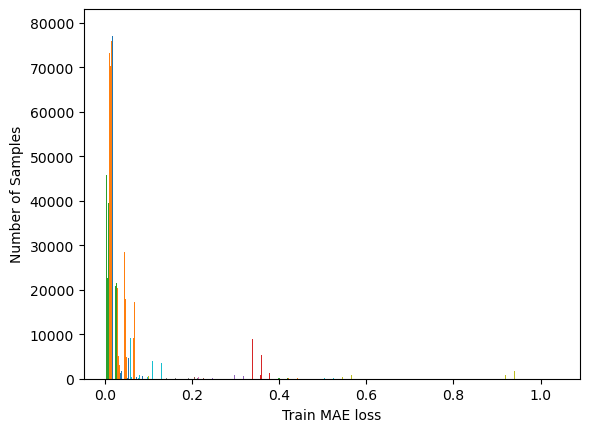

In [61]:
train_pred = model.predict(train_data)

train_mae_loss = np.mean(np.abs(train_pred - train_data), axis=1)

plt.hist(train_mae_loss, bins=50)
plt.xlabel('Train MAE loss')
plt.ylabel('Number of Samples');

threshold = np.max(train_mae_loss)
print(f'Reconstruction error threshold: {threshold}')

Reconstruction error threshold: 0.3563777528021649


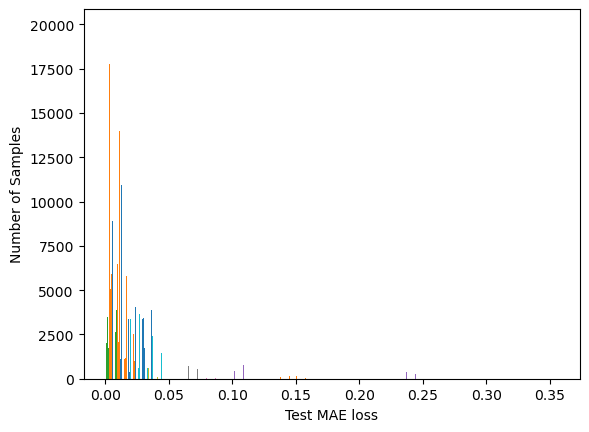

In [60]:
test_mae_loss = np.mean(np.abs(reconstructed_data - test_data), axis=1)

plt.hist(test_mae_loss, bins=50)
plt.xlabel('Test MAE loss')
plt.ylabel('Number of Samples');

threshold = np.max(test_mae_loss)
print(f'Reconstruction error threshold: {threshold}')

(array([[ 4190.,   840.,  5900., ...,     0.,     0.,     0.],
        [    0.,  2212.,  3689., ...,     0.,     0.,     0.],
        [ 3865.,  4813.,  6022., ...,     0.,     0.,     0.],
        ...,
        [ 7938.,  1736., 10194., ...,     0.,     0.,     0.],
        [19868.,     0.,     0., ...,     0.,     0.,     0.],
        [19868.,     0.,     0., ...,     0.,     0.,     0.]]),
 array([1.80547747e-05, 1.18967114e-02, 2.37753680e-02, 3.56540246e-02,
        4.75326812e-02, 5.94113378e-02, 7.12899944e-02, 8.31686510e-02,
        9.50473076e-02, 1.06925964e-01, 1.18804621e-01, 1.30683277e-01,
        1.42561934e-01, 1.54440591e-01, 1.66319247e-01, 1.78197904e-01,
        1.90076560e-01, 2.01955217e-01, 2.13833874e-01, 2.25712530e-01,
        2.37591187e-01, 2.49469843e-01, 2.61348500e-01, 2.73227157e-01,
        2.85105813e-01, 2.96984470e-01, 3.08863126e-01, 3.20741783e-01,
        3.32620440e-01, 3.44499096e-01, 3.56377753e-01]),
 <a list of 70 BarContainer objects>)

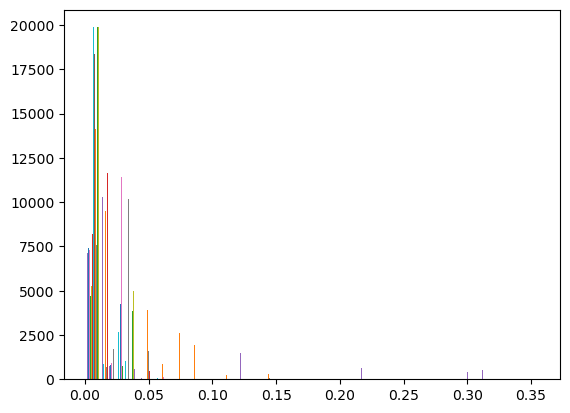

In [62]:
plt.hist(test_mae_loss, bins=30)

In [63]:
import joblib

model_filename = 'C:\\Users\\Gjirafa\\Alberti\\AlbZa\\DS Lab2\\Dataset\\anomaly_detection_lstm_model.pkl'
joblib.dump(model, model_filename)

['C:\\Users\\Gjirafa\\Alberti\\AlbZa\\DS Lab2\\Dataset\\anomaly_detection_lstm_model.pkl']

In [108]:
loaded_model = joblib.load(model_filename)

In [119]:
test_data_scaled

Index(['FIT101', 'LIT101', 'AIT202', 'AIT203', 'FIT201', 'DPIT301', 'FIT301',
       'LIT301', 'AIT401', 'AIT402', 'FIT401', 'LIT401', 'AIT501', 'AIT502',
       'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'PIT501',
       'PIT502', 'PIT503', 'FIT601', 'MV101_0', 'MV101_1', 'MV101_2', 'P101_1',
       'P101_2', 'P102_1', 'P102_2', 'MV201_0', 'MV201_1', 'MV201_2', 'P201_1',
       'P201_2', 'P203_1', 'P203_2', 'P204_1', 'P204_2', 'P205_1', 'P205_2',
       'P206_1', 'P206_2', 'MV301_0', 'MV301_1', 'MV301_2', 'MV302_0',
       'MV302_1', 'MV302_2', 'MV303_0', 'MV303_1', 'MV303_2', 'MV304_0',
       'MV304_1', 'MV304_2', 'P301_1', 'P301_2', 'P302_1', 'P302_2', 'P402_1',
       'P402_2', 'P403_1', 'P403_2', 'UV401_1', 'UV401_2', 'P501_1', 'P501_2',
       'Attack_0', 'Attack_1'],
      dtype='object')

In [120]:
# Create empty lists to store the windowed data and labels.
windowed_test_data = []
labels = []

l = 120
l_overlap = 115

# Determine the stride (step size) for the sliding window with overlap.
stride = l - l_overlap

# Iterate over the data with the sliding window.
for i in range(0, len(test_data_scaled) - l + 1, stride):
    # Extract a window of data.
    window = test_data_scaled[i:i + l]

    # Append the windowed data to the list.
    windowed_test_data.append(window)

    # Extract the corresponding label for this window.
    label = test_data_scaled[[i + l - 1]]  # Adjust this based on the position of your labels.
    labels.append(label)

In [121]:

# Convert the windowed data to a NumPy array.
windowed_data = np.array(windowed_data)

In [ ]:
test_history = loaded_model.predict(windowed_test_data)

In [115]:
windowed_test_data


[array([[0.88414414, 0.45739577, 0.25853021, ..., 1.        , 0.        ,
         0.        ],
        [0.89114463, 0.45744046, 0.25853021, ..., 1.        , 0.        ,
         0.        ],
        [0.90677872, 0.45739577, 0.25612101, ..., 1.        , 0.        ,
         0.        ],
        ...,
        [0.9544977 , 0.45864563, 0.25250785, ..., 1.        , 0.        ,
         0.        ],
        [0.95006397, 0.45811003, 0.25250785, ..., 1.        , 0.        ,
         0.        ],
        [0.94236368, 0.45819929, 0.25250785, ..., 1.        , 0.        ,
         0.        ]]),
 array([[0.95053062, 0.45855637, 0.25612101, ..., 1.        , 0.        ,
         0.        ],
        [0.9606811 , 0.45882417, 0.25612101, ..., 1.        , 0.        ,
         0.        ],
        [0.9661647 , 0.45895813, 0.25612101, ..., 1.        , 0.        ,
         0.        ],
        ...,
        [0.92591287, 0.45877959, 0.25250785, ..., 1.        , 0.        ,
         0.        ],
        [0.9